In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Punts fixos, òrbites periòdiques i estabilitat

**Definició.** Es diu que $x=x^*$ és un punt fix del sistema dinàmic $x_{n+1}=f(x_n)$ si $f(x^*)=x^*$.

Una manera gràfica de trobar els punts fixos en un sistema dinàmic discret de dimensió 1 consisteix en trobar els punts de tall amb la diagonal $y=x$.

**Definició.** La semiòrbita positiva d'un punt $x\in\mathbb{R}$ és el conjunt $O_+(x)=\{x,f(x),f^2(x),\dots,f^n(x),\dots\}$, on $f^n(x)=(f\circ\dots^{n)}\circ f)(x)$.

**Definició.** Sigui $x^*$ punt fix de $x_{n+1}=f(x_n)$. Es diu que $x^*$ és *estable* si $\forall U\subset\mathbb{R}$ entorn obert de $x^*$ existeix un altre entorn $V\subset U$ de $x^*$ tal que $\forall x\in V$ la semiòrbita positiva $O_+(x)\subset U$. Es diu que $x^*$ és *inestable* (o *repulsor*) si $x^*$ no és estable, és a dir, si $\exists U\subset\mathbb{R}$ entorn obert de $x^*$ tal que $\forall V\subset U$ entorn obert de $x^*$ hi ha algun punt $x\in V$ tal que $O_+(x)\not\subset U$.

**Definició.** Sigui $x^*$ un punt fix estable, diem que és *asimptòticament estable* (o *atractor local*) si existeix $U\subset\mathbb{R}$ entorn obert de $x^*$ tal que $\forall x\in U$, $\lim_{n\rightarrow\infty}f^n(x)=x^*$.

**Observació.** Pot haver-hi punts fixos que no són ni atractors locals ni repulsors. Per exemple, en el sistema dinàmic $x_{n+1}=x_n$ tot punt $x\in\mathbb{R}$ és punt fix estable, però cap és asimptòticament estable. També pot haver-hi punts fixos no estables on convergeixen les semiòrbites positives de tots els punts. Per exemple: $x_{n+1}=f(x_n)$ amb $$f(x)=\begin{cases}
2 & \text{si } x \leq 0 \\
-1+2x & \text{si } 0<x\leq 1\\
\frac{1+x}{2} & \text{si } x>1.
\end{cases}
$$

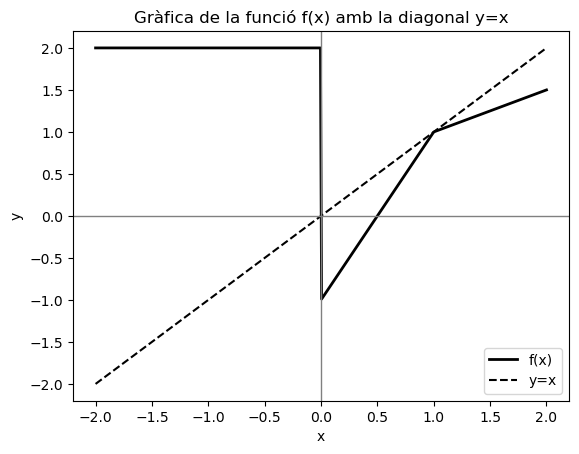

In [11]:
def f(x):
    if x <= 0.0:
        return 2
    elif x <= 1.0:
        return -1 + 2*x
    else:
        return (1 + x)/2

x_vals = np.linspace(-2, 2, 400)
y_vals = [f(x) for x in x_vals]

plt.plot(x_vals, y_vals, 'k-', label='f(x)',linewidth=2)
plt.plot(x_vals,x_vals, 'k--', label='y=x')
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gràfica de la funció f(x) amb la diagonal y=x')
plt.legend()
plt.show()


    

**Definició.** Diem que $p\in\mathbb{R}$ és un punt *periòdic de període* $n$ si $f^n(p)=p$ i $f^j(p)\neq p$ $\forall 0<j<n$. Diem que és un punt *preperiòdic* d'una òrbita periòdica de període $n$ si $\exists m>0$ tal que $f^{m+n}(p)=f^m(p)$ i per tant $f^{n+j}(p)=f^j(p)$ $\forall j\geq m$. En aquest cas $f^m(p)$ és un punt periòdic.

## Estudi de l'estabilitat de punts fixos i òrbites periòdiques

**Teorema.** Sigui $f:\mathbb{R}\rightarrow\mathbb{R}$ de classe $\mathcal{C}^1$.

a) Si $x^*$ és un punt fix de $f$ tal que $|f'(x^*)|<1$ aleshores $x^*$ és un punt fix atractor.

b) Si $p$ és un punt periòdic de període $n$ tal que $|(f^n)'(p)|<1$ aleshores $p$ és un punt periòdic atractor.

*Prova.* (tbd)

**Teorema.** Sigui $f:\mathbb{R}\rightarrow\mathbb{R}$ de classe $\mathcal{C}^1$ i sigui $p$ un punt periòdic de període $n$ tal que $|(f^n)'(p)|>1$. Aleshores $p$ és un punt periòdic repulsor. Més concretament, existeix un interval obert $I$ al voltant de $p$ tal que $\forall x\in I\setminus\{a\}$, $\exists k=k(x)$ tal que $f^{nk}(x)\notin I$.

*Prova.* (tbd)

## Exemple: La dinàmica de l'aplicació logística per $\lambda>0$.

Considerem $f_{\lambda}(x) = \lambda x (1-x)$ amb $\lambda>0$. Anem a veure quins punts fixos té i quina és la seva estabilitat.

De $f_{\lambda}(x) = x$ obtenim que l'aplicació logística té dos punts fixos: $x^*=0$ i $x^*=p_{\lambda}=\frac{\lambda-1}{\lambda}$. Per estudiar la seva estabilitat local, analitzem la derivada de $f_{\lambda}(x)$ respecte de $x$: $f_{\lambda}'(x)=\lambda(1-2x)$.

En el punt fix $x^*=0$ tenim $f_{\lambda}'(0)=\lambda$. Per tant, el punt fix $x^*=0$ serà atractor si $\lambda\in(0,1)$ i repulsor si $\lambda>1$ (d'això en direm bifurcació més endavant). A més, com que el signe de $f_{\lambda}'(0)>0$, tant l'atracció com la repulsió són monòtones.

Per $x^*=p_{\lambda}$ tenim $f_{\lambda}'(p_{\lambda}) = 2-\lambda$. Això implica que $p_{\lambda}$ és atractor quan $\lambda\in(1,3)$ i repulsor quan $\lambda\in(0,1)\cup(3,\infty)$.

Observem que, justament a $\lambda=1$, $p_1=0$ i els dos punts fixos coincideixen. A més, és just el moment en que es produeix un canvi d'estabilitat entre ells. En la secció següent estudiarem aquest tipus de fenòmen.

Anem a veure si existeixen òrbites 2-periòdiques. Aquestes seran punts fixos de $f_{\lambda}^2$ que no siguin punts fixos de $f_{\lambda}$. Considerem $$f_{\lambda}^2(x)=\lambda(\lambda x(1-x))(1-\lambda x(1-x))=x.$$ Resolent obtenim quatre solucions: dues són els punts fixos de $f_{\lambda}$, les altres dues corresponen als dos punts periòdiques de període $2$:
$$ x_{\pm}(\lambda) = \frac{1+\lambda\pm\sqrt{\lambda^2-2\lambda-3}}{2\lambda}.$$

Per tal que aquestes solucions existeixin (siguin reals) cal que el discriminant sigui no negatiu. En aquest cas, $\lambda\leq -1$ o $\lambda\geq 3$. Per tant, per $\lambda\in(0,3)$ no existeixen òrbites 2-periòdiques, per $\lambda>3$ sí que existeix. Per veure'n l'estabilitat, cal calcular la derivada de $g_{\lambda}(x)=f_{\lambda}^2(x)$ en els punts periòdics: $$g_{\lambda}'(x) = 4\lambda^2\left(\frac{1}{2}-\lambda x(1-x)\right)\left(\frac{1}{2}-x\right) \Longrightarrow g_{\lambda}'(x_{\pm}(\lambda))=-\lambda^2+2\lambda+4.$$ Observem que la funció anterior satisfà $|g_{\lambda}'(x_{\pm}(\lambda))|<1$ quan $\lambda\in(3,1+\sqrt{6})\approx(3,3.45)$. Per tant, en aquesta regió de paràmetres l'òrbita $2$-periòdica és estable.

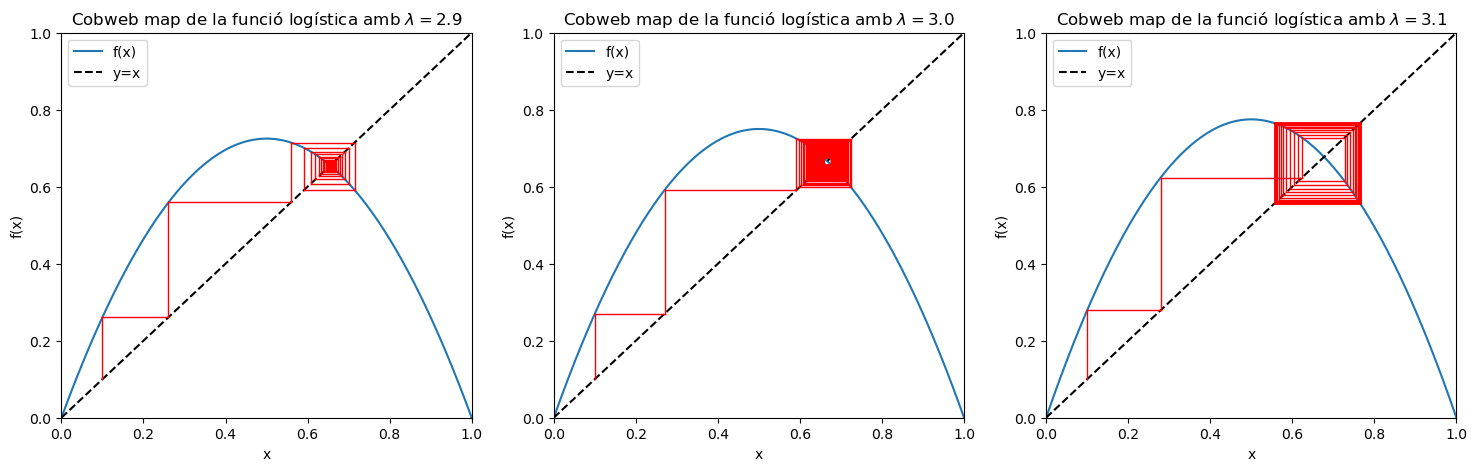

In [29]:
# funció logística
def f(x, lam):
    return lam*x*(1-x)

# paràmetres
lam1 = 2.9
lam2 = 3.0
lam3 = 3.1
x0 = 0.1
N = 50

x = np.linspace(0,1,400)
fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].plot(x, f(x,lam1), label="f(x)")
axes[0].plot(x, x, 'k--', label="y=x")
x_n = x0
for i in range(N):
    y_n = f(x_n, lam1)
    axes[0].plot([x_n, x_n], [x_n, y_n], 'r', linewidth=1)
    axes[0].plot([x_n, y_n], [y_n, y_n], 'r', linewidth=1)
    x_n = y_n
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Cobweb map de la funció logística amb $\lambda=2.9$")
axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)
axes[0].legend()

axes[1].plot(x, f(x,lam2), label="f(x)")
axes[1].plot(x, x, 'k--', label="y=x")
x_n = x0
for i in range(10*N):
    y_n = f(x_n, lam2)
    axes[1].plot([x_n, x_n], [x_n, y_n], 'r', linewidth=1)
    axes[1].plot([x_n, y_n], [y_n, y_n], 'r', linewidth=1)
    x_n = y_n
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].set_title("Cobweb map de la funció logística amb $\lambda=3.0$")
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)
axes[1].legend()

axes[2].plot(x, f(x,lam3), label="f(x)")
axes[2].plot(x, x, 'k--', label="y=x")
x_n = x0
for i in range(N):
    y_n = f(x_n, lam3)
    axes[2].plot([x_n, x_n], [x_n, y_n], 'r', linewidth=1)
    axes[2].plot([x_n, y_n], [y_n, y_n], 'r', linewidth=1)
    x_n = y_n
axes[2].set_xlabel("x")
axes[2].set_ylabel("f(x)")
axes[2].set_title("Cobweb map de la funció logística amb $\lambda=3.1$")
axes[2].set_xlim(0,1)
axes[2].set_ylim(0,1)
axes[2].legend()
plt.show()